In [7]:
!pip install tensorflow matplotlib seaborn scikit-learn pandas numpy

TensorFlow version: 2.21.0
Dataset ready!
Found 120 images belonging to 2 classes.
Found 28 images belonging to 2 classes.
Found 40 images belonging to 2 classes.

Dataset:
Train: 120
Validation: 28
Test: 40
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


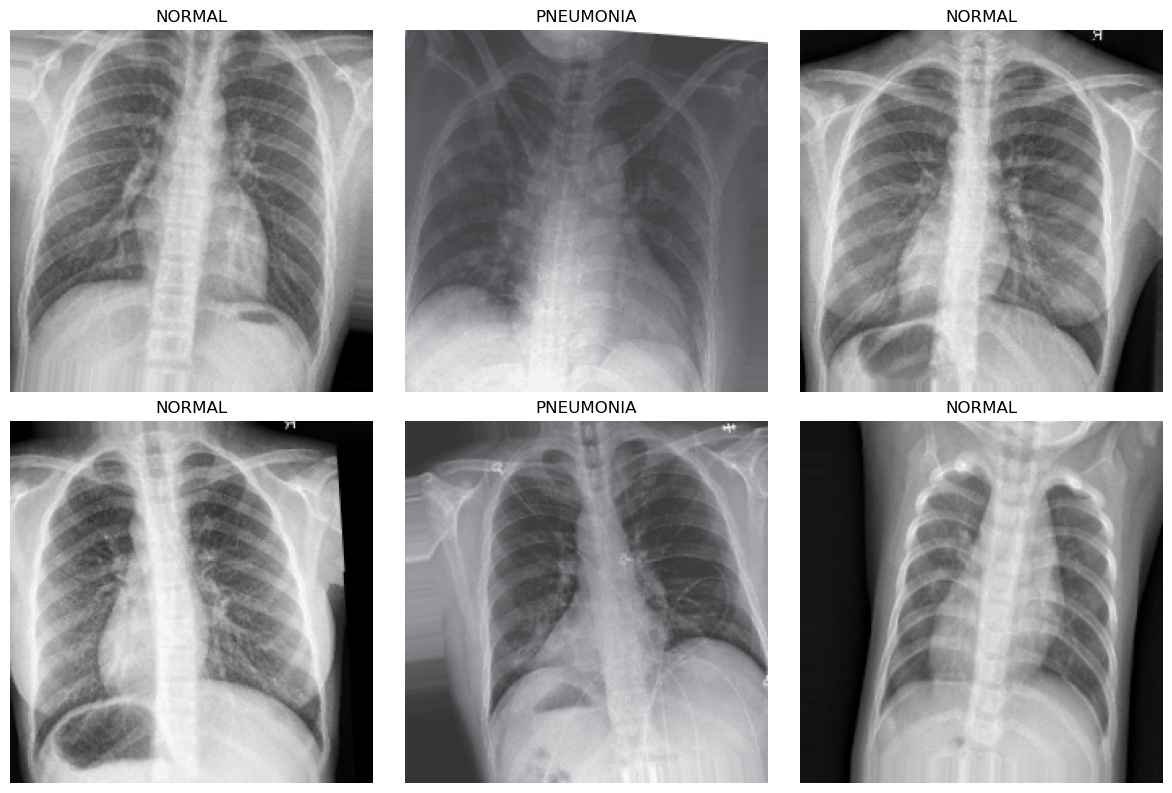

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5167 - loss: 0.7662 - val_accuracy: 0.5000 - val_loss: 0.6816
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5667 - loss: 0.6807 - val_accuracy: 0.8214 - val_loss: 0.6270
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6750 - loss: 0.6192 - val_accuracy: 0.8571 - val_loss: 0.4377
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8083 - loss: 0.4371 - val_accuracy: 0.8571 - val_loss: 0.3202
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7750 - loss: 0.4704 - val_accuracy: 0.8214 - val_loss: 0.4223
Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.5083 - loss: 0.7185 - val_accuracy: 0.5357 - val_loss: 0.6421
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.6667 - loss: 0.6208 - val_accuracy: 0.6429 - val_loss: 0.5910
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8000 - loss: 0.5059 - val_accuracy: 0.7857 - val_loss: 0.5042
Epoch 5/5
8/8 ━━

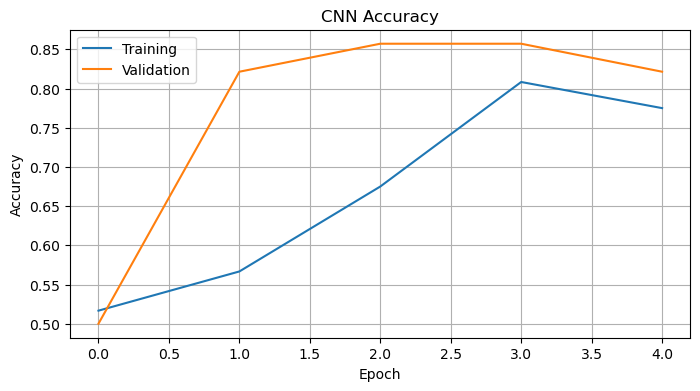

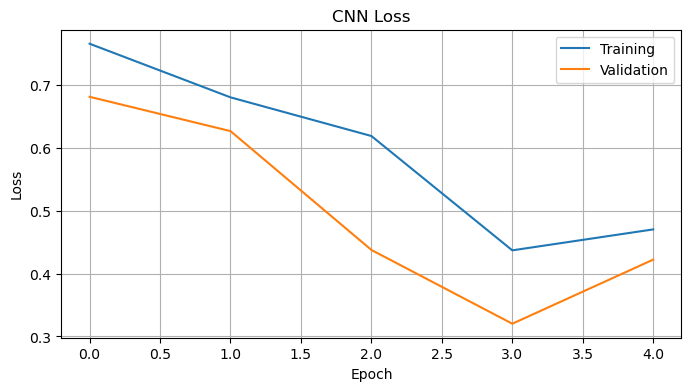

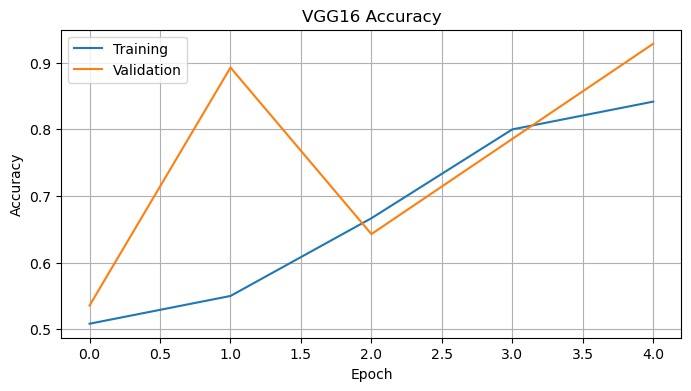

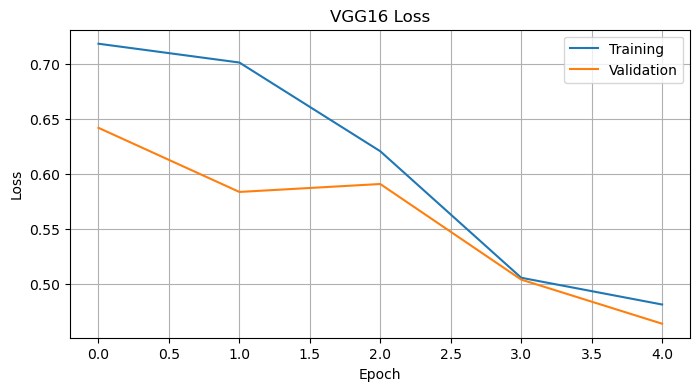

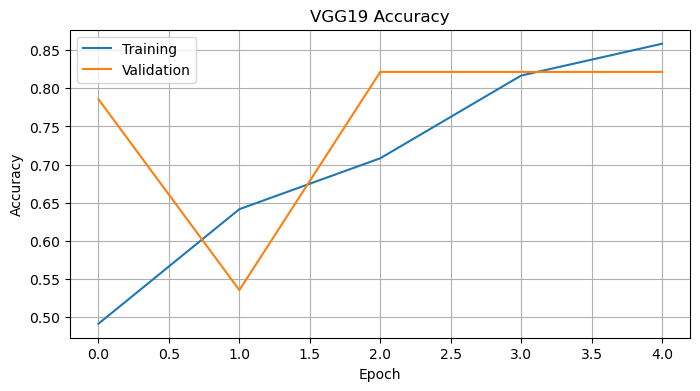

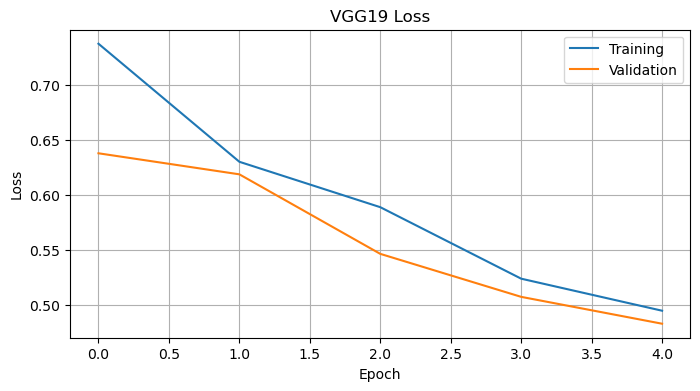

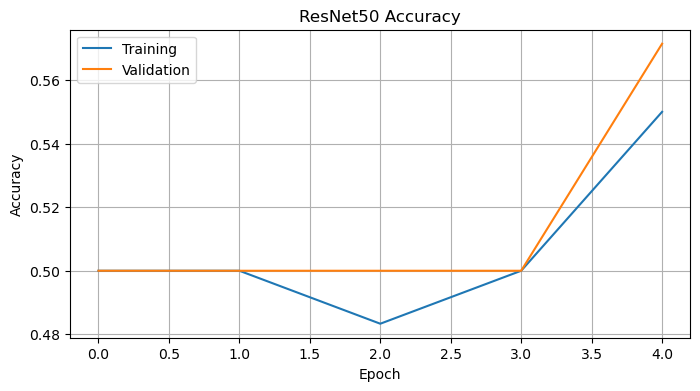

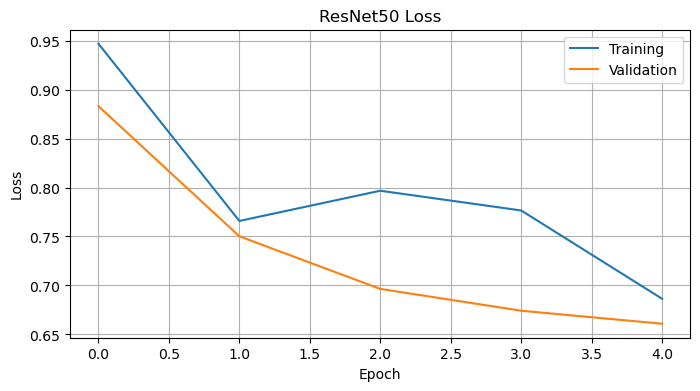


MODEL COMPARISON
      Model  Accuracy  Precision  Recall  F1-Score
0       CNN      97.5     100.00    95.0     97.44
1     VGG16      95.0      90.91   100.0     95.24
2     VGG19      92.5     100.00    85.0     91.89
3  ResNet50      52.5      51.28   100.0     67.80


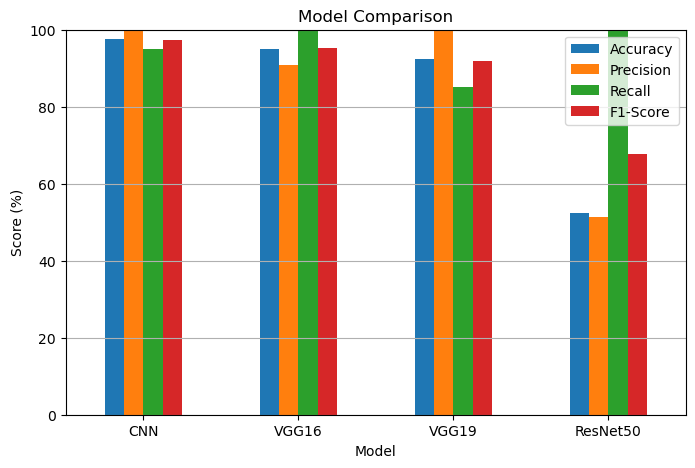

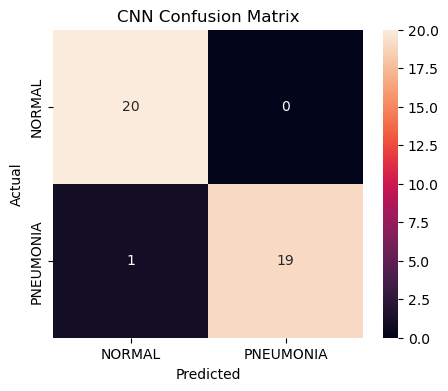

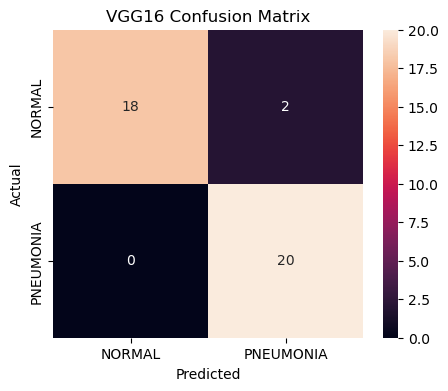

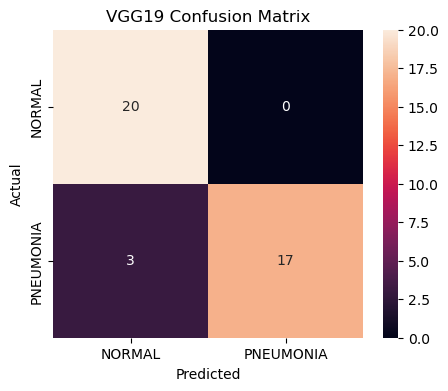

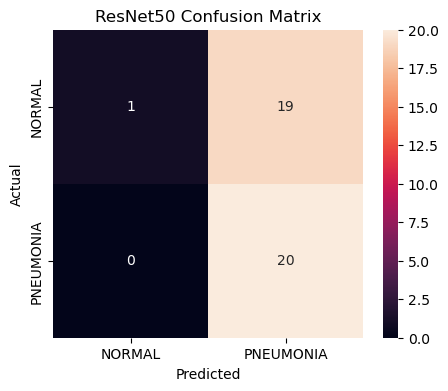


All 4 models saved successfully!

IMAGE PREDICTION
Prediction : PNEUMONIA
Confidence : 57.09 %


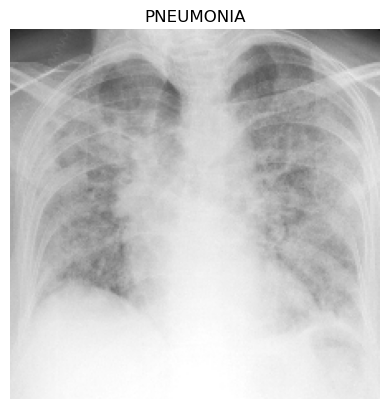

In [65]:
 

# =========================
# 1. IMPORTS
# =========================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19, ResNet50

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

print("TensorFlow version:", tf.__version__)


# =========================
# 2. EXTRACT DATASET
# =========================

zip_path = "nndl!1.zip"
extract_path = "nndl!1_dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset ready!")


# =========================
# 3. DATASET PATHS
# =========================

train_dir = r"nndl!1_dataset\xray_dataset_covid19\train"
val_dir   = r"nndl!1_dataset\xray_dataset_covid19\val"
test_dir  = r"nndl!1_dataset\xray_dataset_covid19\test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16


# =========================
# 4. DATA GENERATORS
# =========================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nDataset:")
print("Train:", train_generator.samples)
print("Validation:", val_generator.samples)
print("Test:", test_generator.samples)
print("Classes:", train_generator.class_indices)



# sample of image in dataset

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    
    if labels[i] == 0:
        plt.title("NORMAL")
    else:
        plt.title("PNEUMONIA")
        
    plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 5. CNN MODEL
# ============================================================

cnn_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


# ============================================================
# 6. VGG16 MODEL
# ============================================================

vgg16_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

vgg16_base.trainable = False

vgg16_model = keras.Sequential([
    vgg16_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

vgg16_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_vgg16 = vgg16_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


# ============================================================
# 7. VGG19 MODEL
# ============================================================

vgg19_base = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

vgg19_base.trainable = False

vgg19_model = keras.Sequential([
    vgg19_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

vgg19_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_vgg19 = vgg19_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


# ============================================================
# 8. RESNET50 MODEL
# ============================================================

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

resnet_base.trainable = False

inputs = keras.Input(shape=(224,224,3))

x = resnet_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

resnet_model = keras.Model(inputs, outputs)

resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


# ============================================================
# 9. ACCURACY & LOSS PLOTS
# ============================================================

histories = {
    "CNN": history_cnn,
    "VGG16": history_vgg16,
    "VGG19": history_vgg19,
    "ResNet50": history_resnet
}

for name, history in histories.items():

    plt.figure(figsize=(8,4))

    plt.plot(
        history.history["accuracy"],
        label="Training"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation"
    )

    plt.title(name + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8,4))

    plt.plot(
        history.history["loss"],
        label="Training"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation"
    )

    plt.title(name + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


# ============================================================
# 10. MODEL COMPARISON
# ============================================================

models = {
    "CNN": cnn_model,
    "VGG16": vgg16_model,
    "VGG19": vgg19_model,
    "ResNet50": resnet_model
}

y_true = test_generator.classes

results = []

for name, model in models.items():

    test_generator.reset()

    pred = (
        model.predict(test_generator, verbose=0) >= 0.5
    ).astype(int).ravel()

    results.append([
        name,
        accuracy_score(y_true, pred) * 100,
        precision_score(y_true, pred, zero_division=0) * 100,
        recall_score(y_true, pred, zero_division=0) * 100,
        f1_score(y_true, pred, zero_division=0) * 100
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

comparison_df.iloc[:,1:] = comparison_df.iloc[:,1:].round(2)

print("\nMODEL COMPARISON")
print(comparison_df)


# Comparison graph

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score (%)")
plt.ylim(0,100)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)


# ============================================================
# 11. CONFUSION MATRICES
# ============================================================

for name, model in models.items():

    test_generator.reset()

    pred = (
        model.predict(test_generator, verbose=0) >= 0.5
    ).astype(int).ravel()

    cm = confusion_matrix(y_true, pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["NORMAL", "PNEUMONIA"],
        yticklabels=["NORMAL", "PNEUMONIA"]
    )

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ============================================================
# 12. SAVE ALL MODELS
# ============================================================

cnn_model.save("pneumonia_cnn_model.keras")
vgg16_model.save("pneumonia_vgg16_model.keras")
vgg19_model.save("pneumonia_vgg19_model.keras")
resnet_model.save("pneumonia_resnet50_model.keras")

print("\nAll 4 models saved successfully!")


# ============================================================
# 13. SINGLE IMAGE PREDICTION
# ============================================================

from tensorflow.keras.preprocessing import image

img_path = r"C:\Users\Devika\ nndl oe\nndl!1_dataset\xray_dataset_covid19\single prediction\normal_or_pneumonia2.jpeg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Using ResNet50
prediction = resnet_model.predict(
    img_array,
    verbose=0
)[0][0]

if prediction >= 0.5:
    result = "PNEUMONIA"
    confidence = prediction * 100
else:
    result = "NORMAL"
    confidence = (1 - prediction) * 100

print("\nIMAGE PREDICTION")
print("Prediction :", result)
print("Confidence :", round(confidence,2), "%")

plt.imshow(img)
plt.axis("off")
plt.title(result)
plt.show()

File exists: True
Prediction : PNEUMONIA
Confidence : 57.09 %


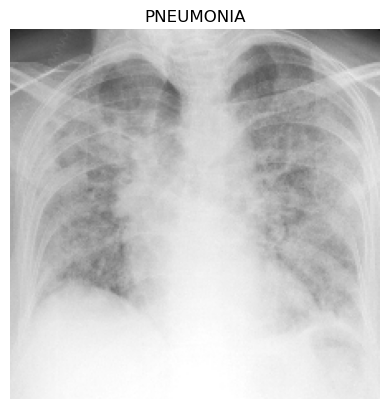

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

img_path = r"C:\Users\Devika\ nndl oe\nndl!1_dataset\xray_dataset_covid19\single prediction\normal_or_pneumonia2.jpeg"

# Check whether file exists
print("File exists:", os.path.exists(img_path))

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert image
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict using ResNet50
prediction = resnet_model.predict(img_array, verbose=0)[0][0]

# Result
if prediction >= 0.5:
    result = "PNEUMONIA"
    confidence = prediction * 100
else:
    result = "NORMAL"
    confidence = (1 - prediction) * 100

print("Prediction :", result)
print("Confidence :", round(confidence, 2), "%")

# Display image
plt.imshow(img)
plt.axis("off")
plt.title(result)
plt.show()